In [2]:
!pip install qutip cvxpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 34.7 MB/s eta 0:00:00


In [ ]:
# Code for the kicked coupled top unitary 
import numpy as np
from qutip import *

j1 = 15   # spin of system A'
j2 = 15 # spin of system B'

k1 = 2.0 # kick for system A'
k2 = 5.0 # kick for system B'
alpha1 = 0.35
alpha2 = 0.4

epsilon = 30.2  # coupling strength

# Dimensions
d1prime = int(2*j1 + 1) #dim HA'
d2prime = int(2*j2 + 1) #dim HB'
print('d1',d1prime)

#Angular momentum operators
Jx1, Jy1, Jz1 = jmat(j1, 'x'), jmat(j1, 'y'), jmat(j1, 'z')
Jx2, Jy2, Jz2 = jmat(j2, 'x'), jmat(j2, 'y'), jmat(j2, 'z')
#print(Jx1)

# Identity operators
I1 = qeye(d1prime)
I2 = qeye(d2prime)

# Local unitaries

UA = (-1j * (k1/(2*j1)) * (Jz1 + alpha1)**2).expm() * \
     (-1j * (np.pi/2) * Jy1).expm()

UB = (-1j * (k2/(2*j2)) * (Jz2 + alpha2)**2).expm() * \
     (-1j * (np.pi/2) * Jy2).expm()

# Tensor product
U_local = tensor(UA, UB)

# Interaction Unitary
V12 = tensor(Jz1, Jz2) / np.sqrt(j1 * j2) # Normalize it

U12 = (1j * epsilon * V12).expm()

# Full floquet unitary
U = U12 * U_local    
print(np.shape(U))

#This U acts from HA'*HB' -> HA*HB



d1 31
(961, 961)


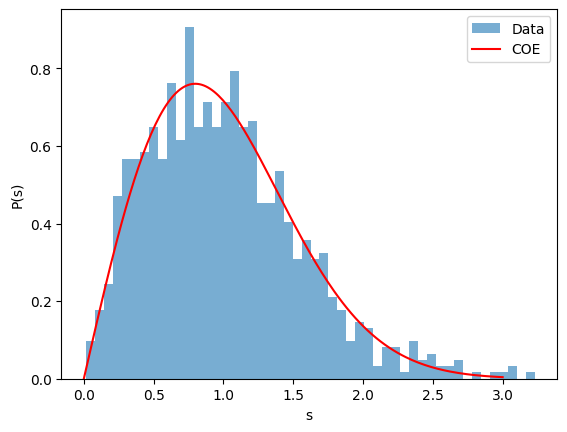

In [ ]:
# Code for level spacing 
import numpy as np
import matplotlib.pyplot as plt

U = U.full()

# 1. Eigenvalues
eigvals = np.linalg.eigvals(U)

# 2. Phases in [0, 2π)
theta = np.angle(eigvals)
theta = np.mod(theta, 2*np.pi)

# 3. Sort
theta = np.sort(theta)
N = len(theta)

# 4. Spacings (including wrap-around)
delta = np.diff(theta)
delta = np.append(delta, 2*np.pi - theta[-1] + theta[0])

# 5. Normalize
s = delta * N / (2*np.pi)

# 6. Histogram
plt.hist(s, bins=50, density=True, alpha=0.6, label='Data')

# COE prediction
x = np.linspace(0, 3, 200)
P_coe = (np.pi/2)*x*np.exp(-np.pi*x**2/4)
plt.plot(x, P_coe, 'r-', label='COE')

plt.xlabel('s')
plt.ylabel('P(s)')
plt.legend()
plt.show()